# Project 03: Gibbs Sampling (Random Algorithm)

In [167]:
import random
import numpy as np
import bamnostic as bs
import seqlogo as sl
from numpy.ma.extras import cov

#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import reverse_complement
import importlib
import motif_ops
importlib.reload(motif_ops)
from motif_ops import *

---
## Implement Gibbs Sampler


Gibbs sampling is a MCMC approach to identify enrichments. Here we will implement a method to identify motifs from a set of regions. 

Important considerations:
- We will need to score each sequence with a PWM using the `score_kmer()` or `score_sequence()` functions
    - You will need to investigate into the help documenation and libraries to identify how best to use these functions. 
- These sites are often not strand-specific and so both scores on the negative as well as positive strand should be considered
- To select a random sequence, use `random.randint()` or `numpy.random.randint()`
- To select a new position $m$ (as defined below) use `random.choices()` or `numpy.random.choice()`  

Assumptions: 
- We know $k$ as the length of expected motif
- Each sequence contains the motif



```
GibbsMotifFinder(DNA, k-length)
    random pick of k-length sequences from each line of DNA as Motifs
    for j ← 1 to 10000 or Motifs stops changing
        i ← Random(N) where N is number of DNA entries
        PWM ← PWM constructed from all Motifs except for Motifi
        Motifi ← select position m from PWM-scored k-mers in DNAi in probabilistic fashion from score distribution
    return PFM
```

Probability of chosing position $m = \frac{A_{m}}{\sum_{l}A_{l}}$ for positions $l$ in DNAi


**Note:** I have also added a function to `motif_ops.py` that will calculate the information content of your motifs. This is useful to observe the progression of your Gibbs sampler as well as a measure of convergence. You can use this function as `IC = pfm_ic(pfm)`. You should expect a slow increase of IC until it plateaus such as in the plot below from your lecture slides:

<center><img src='figures/Gibbs_Sampling.png'/ width=600px></center>

---
# Setting up the data

This BAM file contains a subsampled set of aligned ChIP‑seq reads from a p53 immunoprecipitation experiment in human K562 cells treated with the anthracycline drug daunorubicin. The original SRA experiment SRX5865974 (run SRR9090854) reports 31.2 million Illumina NextSeq 500 ChIP‑seq read pairs from K562 wild‑type cells exposed to daunorubicin, using a p53 antibody to pull down p53‑bound chromatin fragments before library preparation and sequencing. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC4366240/)

### What the data represent

- Biological system: human K562 leukemia cells (Homo sapiens) treated with daunorubicin, a DNA‑damaging chemotherapeutic known to stabilize and activate p53. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC6561911/)
- Assay: ChIP‑seq using an antibody against p53, so reads should be enriched around genomic regions where p53 is bound after drug treatment. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC4526040/)
- Sequencing: Illumina NextSeq 500, with the raw run SRR9090854 corresponding to experiment SRX5865974. [github](https://github.com/ncbi/sra-tools/issues/213)
- BAM file: `SRR9090854.subsampled_5pct.bam` is a coordinate‑sorted alignment file containing ~5% of the original mapped reads, typically created by random down‑sampling the full BAM to reduce file size and speed up exploratory analyses while preserving the overall distribution of p53 binding events. [ecseq](https://www.ecseq.com/support/ngs-snippets/how-to-extract-a-list-of-specific-read-IDs-from-a-BAM-file)

### How `bamnostic` is used and what your code does

The `bamnostic` package provides a pure‑Python interface to BAM files that mirrors the `pysam` API, including an `AlignmentFile` class whose iterator yields `AlignedSegment` objects representing individual aligned reads. In your code: [bamnostic.readthedocs](https://bamnostic.readthedocs.io/en/latest/bamnostic.html)

```python
bam_path = "data/SRR9090854.subsampled_5pct.bam"

seqs = [read.seq for read in bs.AlignmentFile(bam_path)]
```

- `bs.AlignmentFile(bam_path)` opens the BAM file as an `AlignmentFile` object in binary read mode (default `'rb'`), reading the BAM header (reference contigs, read groups, etc.) and preparing a streaming interface to all aligned records. [github](https://github.com/betteridiot/bamnostic/blob/master/docs/source/quickstart.rst)
- Iterating over `AlignmentFile` (`for read in bs.AlignmentFile(...)`) returns each aligned read as a `bamnostic.AlignedSegment` object, which exposes properties analogous to SAM fields such as query name, flags, reference name, position, mapping quality, CIGAR string, and the original sequencing **sequence**. [bamnostic.readthedocs](https://bamnostic.readthedocs.io/en/latest/bamnostic.html)
- The `read.seq` attribute is the query (read) sequence string stored in the BAM, corresponding to the full read sequence (including any unaligned bases), as opposed to `query_alignment_sequence`, which would only contain the aligned portion. [bamnostic.readthedocs](https://bamnostic.readthedocs.io/en/latest/bamnostic.html)
- The list comprehension `[read.seq for read in ...]` consumes the entire BAM stream and collects the nucleotide sequences from every subsampled ChIP‑seq read into a Python list `seqs`, which can then be used for downstream tasks such as motif discovery, k‑mer analysis, or quality checks on read content. [ucdavis-bioinformatics-training.github](https://ucdavis-bioinformatics-training.github.io/2022-Feb-Introduction-To-Python-For-Bioinformatics/python/python5)

In summary, your dataset is a 5% random sample of p53‑ChIP‑seq alignments from daunorubicin‑treated K562 cells, and the `bamnostic` code opens the subsampled BAM and extracts the raw read sequences from each aligned fragment into memory as a list.

In [3]:
bam_path = "data/SRR9090854.subsampled_5pct.bam"

seqs = [read.seq for read in bs.AlignmentFile(bam_path)]

In [290]:
import subprocess
import os

macs3_path = "/Users/chanteralazard/.local/share/virtualenvs/BINF6250_GIBBS_SAMPLING-z8WBSOuk/bin/macs3"
output_dir = "macs3_output"
os.makedirs(output_dir, exist_ok=True)

In [293]:
results = subprocess.run(
    [macs3_path, "callpeak",
     "-t", bam_path,
     "-f", "BAM",
     "-g", "hs",
     "-n", "p53",
     "--outdir", output_dir,
     "-q", "0.05"],
    capture_output=True,
    text=True
)

print(results.stdout)
if results.returncode != 0:
    print("Error:", results.stderr)

In [314]:
import pandas as pd

peaks_path = "macs3_output/p53_peaks.narrowPeak"
peaks = pd.read_csv(peaks_path, sep="\t", header=None, names=["chrom", "start_pos", "end_pos", "name", "score", "strand", "signalValue", "pValue", "qValue", "peak"])


# Filter by qvalue (>10)
high_confidence_peaks = peaks[peaks['qValue'] > 10].copy()

# Filter by signalValue
high_confidence_peaks_2 = high_confidence_peaks[high_confidence_peaks['signalValue'] > 16].copy()



print(f"Original peaks: {len(peaks)}")
print(f"High Confidence peaks (q > 10): {len(high_confidence_peaks)}")
print(f'High confidence peaks (signalValue > 16): {len(high_confidence_peaks_2)}')


Original peaks: 528
High Confidence peaks (q > 10): 359
High confidence peaks (signalValue > 16): 91


In [326]:
# Get peak positions
#print(high_confidence_peaks_2.head())

# We need chromosome #s
chromosomes = [high_confidence_peaks_2['chrom'].unique()]

# Calculate summit as Point-source called for this peak; 0-based offset from chromStart
high_confidence_peaks_2['summit_pos'] = high_confidence_peaks_2['start_pos'] + high_confidence_peaks_2['peak']

print(high_confidence_peaks_2.head())

   chrom  start_pos    end_pos         name  score strand  signalValue  \
12     1   72466479   72466871  p53_peak_13    593      .      22.0386   
15     1  111757051  111757463  p53_peak_16    540      .      19.9852   
21     1  142705650  142706046  p53_peak_22    759      .      22.4242   
22     1  142834092  142834543  p53_peak_23   2004      .      27.4012   
23     1  143202109  143202511  p53_peak_24    673      .      21.6607   

      pValue    qValue  peak  summit_pos  
12   64.9923   59.3787   192    72466671  
15   59.6170   54.0727   213   111757264  
21   81.7371   75.9301   198   142705848  
22  207.6130  200.4030   222   142834314  
23   73.0776   67.3796   189   143202298  


In [330]:
peak_positions = pd.DataFrame()
peak_positions['chrom'] = high_confidence_peaks_2['chrom']
peak_positions['motif_start_pos'] = high_confidence_peaks_2['summit_pos'] - flank_size
peak_positions['motif_end_pos'] = high_confidence_peaks_2['summit_pos'] + flank_size
print(peak_positions.head())

   chrom  motif_start_pos  motif_end_pos
12     1         72466621       72466721
15     1        111757214      111757314
21     1        142705798      142705898
22     1        142834264      142834364
23     1        143202248      143202348


In [353]:
background_positions = pd.DataFrame()
background_positions['chrom'] = high_confidence_peaks_2['chrom']
background_positions['start_pos_lf'] = high_confidence_peaks_2['start_pos']
background_positions['end_lf'] = high_confidence_peaks_2['summit_pos'] -   flank_size -1
background_positions['start_pos_rf'] = high_confidence_peaks_2['summit_pos'] + flank_size + 1
background_positions['end_rf'] = high_confidence_peaks_2['end_pos']
print(background_positions.head())

   chrom  start_pos_lf     end_lf  start_pos_rf     end_rf
12     1      72466479   72466620      72466722   72466871
15     1     111757051  111757213     111757315  111757463
21     1     142705650  142705797     142705899  142706046
22     1     142834092  142834263     142834365  142834543
23     1     143202109  143202247     143202349  143202511


In [358]:
print(len(background_positions))

91


In [357]:
from pyfaidx import Fasta
import gcsfs

import requests
import time

def get_sequence_b37(chrom, start, end):
    """Fetch sequence from Ensembl (uses b37 naming)"""
    # Ensembl uses GRCh37 (equivalent to b37)
    url = f"https://grch37.rest.ensembl.org/sequence/region/human/{chrom}:{start}..{end}:1"
    headers = {"Content-Type": "text/plain"}

    response = requests.get(url, headers=headers)
    if response.ok:
        return response.text.upper()
    return None

# Use it
sequences = []
for counter, (idx, row) in enumerate(peak_positions.iterrows()):
    chrom = row['chrom']
    seq_start = row['motif_start_pos']
    seq_end = row['motif_end_pos']
    seq = get_sequence_b37(chrom, seq_start, seq_end)
    if seq:
        sequences.append(seq)

    time.sleep(0.1)  # Rate limiting
    if idx % 10 == 0:
        print(f"Extracted {counter+1}/{len(peaks_positions)}")

Extracted 51/528
Extracted 131/528
Extracted 141/528
Extracted 251/528
Extracted 291/528
Extracted 331/528
Extracted 401/528
Extracted 431/528


In [360]:
background_sequences = []
for counter, (idx, row) in enumerate(background_positions.iterrows()):
    chrom = row['chrom']
    seq_start_lf = row['start_pos_lf']
    seq_end_lf = row['end_lf']
    seq_start_rf = row['start_pos_rf']
    seq_end_rf = row['end_rf']
    seq_lf = get_sequence_b37(chrom, seq_start_lf, seq_end_lf)
    seq_rf = get_sequence_b37(chrom, seq_end_rf, seq_end_rf)
    if seq_lf and seq_rf:
        seq = seq_lf + seq_rf
        background_sequences.append(seq)

    time.sleep(0.1)  # Rate limiting
    if idx % 10 == 0:
        print(f"Extracted {counter+1}/{len(background_positions)}")

Extracted 13/91
Extracted 22/91
Extracted 26/91
Extracted 42/91
Extracted 50/91
Extracted 56/91
Extracted 71/91
Extracted 78/91


In [361]:
print(min(len(seq) for seq in sequences))
print(max(len(seq) for seq in sequences))
print(background_sequences)

101
101
['TTATATTCTCAGGATCTAGATAGTCAAAATGAAAGAGGAAAGAAAAAACCTGACAGGCAGGTAGTTCGGGTGGGTCCTTGGATGAGTTCTTTCAAACAAAAGGACAGCCTGAAGGCACAGATAAGGGAACTTGCAAAGGAGAA', 'GGACCCAGAAAAGGGTTACCATTTTTACAGTTGAATGCAAAGGTTTTTACAGGAAACCAATAAGGGCTGGGGATCTCATTTGCATAGGTACGAATTTCTGGTAGCTCTACCTTGTTCTTCTAATGCACATGTGGGCCCTTAGCTTGAGTTACTCCGTATTGCTT', 'ATGTATCCATACAATGGAATATTACTCAGCAATAAGAAGAAATTAAGTACAGATACCGTATTAGGAGGAGACAGCAAAATGCCTAGGCAGATACGGAAGGGTCCCCGGAGAATCTCCAACCAGCCCCACAAGTGTTTACACCAGATGTG', 'CTCATGACCAGGAAAAATTAAGCCTGCAGACACATTGAGGAGGGCAGAATTTATTATGTGAAAGCACAGCTCTCAGCAAAGAGAGGGGTCCTGCAAAGAGGTTTCCACCTCACAATTGAATACCAGGAGCACATGAGCTGAAGCGGCCAGGCTCCTCCTCTGCATAAGGTGTT', 'AATAAAATGTTTGATGTATCCATACAATGGAATATTACTCAGCAATAAGAAGAAATTAAGTACAGATACCGTATTAGGAGGAGACAGCAAAATGCCTAGGCAGATACGGAAGGGTCCCTGGAGAATCTCCAACCAGCCCT', 'GTGACCAGGAAAAATTAAGCATGCAGACACATTGAGGAGGGCAGAATTTATTATGTGAAAGCACAGCTCTCAGCAAAGAGAGGGGTCCTGCAAAGAGGTTTCCACCTCACAATTGAATACCAGGAGCACATGAGCTGAAGCGGCCAGGCTCCTCCTCTGCATAAGGTGTT', 'TGGGCCCCCTGACAGTGACCGTGACTC

In [350]:
sequences_w_complement = []
for seq in sequences:
    if 'N' not in seq:
        sequences_w_complement.append(seq)
        sequences_w_complement.append(reverse_complement(seq))
print(len(sequences_w_complement))

182


In [306]:
bam = bs.AlignmentFile('data/SRR9090854.subsampled_5pct.bam')
#next_read = next(bam)
dir(next_read)

['_AlignedSegment__hash_key',
 '_AlignedSegment__qa_end',
 '_AlignedSegment__qa_seq',
 '_AlignedSegment__qa_start',
 '_AlignedSegment__reference_end',
 '_AlignedSegment__reference_length',
 '_AlignedSegment__reference_start',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_bin_mq_nl',
 '_byte_seq',
 '_byte_stream',
 '_cigar',
 '_cigar_builder',
 '_cigartuples',
 '_decode_cigar',
 '_flag_nc',
 '_io',
 '_l_read_name',
 '_n_cigar_op',
 '_qual_builder',
 '_query_alignment_attrs',
 '_range_popper',
 '_raw_qual',
 '_raw_stream',
 '_reference_attrs',
 '_seq_builder',
 '_tag_builder',
 '_tagger',
 '_unpack_data',

In [305]:
print(bam.header)   # Homo_sapiens_assembly19.fasta

{'HD': [{'VN': '1.5', 'SO': 'coordinate'}], 'SQ': [{'SN': 1, 'LN': 249250621}, {'SN': 2, 'LN': 243199373}, {'SN': 3, 'LN': 198022430}, {'SN': 4, 'LN': 191154276}, {'SN': 5, 'LN': 180915260}, {'SN': 6, 'LN': 171115067}, {'SN': 7, 'LN': 159138663}, {'SN': 8, 'LN': 146364022}, {'SN': 9, 'LN': 141213431}, {'SN': 10, 'LN': 135534747}, {'SN': 11, 'LN': 135006516}, {'SN': 12, 'LN': 133851895}, {'SN': 13, 'LN': 115169878}, {'SN': 14, 'LN': 107349540}, {'SN': 15, 'LN': 102531392}, {'SN': 16, 'LN': 90354753}, {'SN': 17, 'LN': 81195210}, {'SN': 18, 'LN': 78077248}, {'SN': 19, 'LN': 59128983}, {'SN': 20, 'LN': 63025520}, {'SN': 21, 'LN': 48129895}, {'SN': 22, 'LN': 51304566}, {'SN': 'X', 'LN': 155270560}, {'SN': 'Y', 'LN': 59373566}, {'SN': 'MT', 'LN': 16569}, {'SN': 'GL000207.1', 'LN': 4262}, {'SN': 'GL000226.1', 'LN': 15008}, {'SN': 'GL000229.1', 'LN': 19913}, {'SN': 'GL000231.1', 'LN': 27386}, {'SN': 'GL000210.1', 'LN': 27682}, {'SN': 'GL000239.1', 'LN': 33824}, {'SN': 'GL000235.1', 'LN': 34474

In [279]:
print(next_read)

22	99	1	10059	0	37M	=	10253	231	CCTAACCCTAACCCTAACCCTAACCCTATCCAGATCG	AAAAAEEEEEEEEEEEEEEEEAEE/AEE/EE//E/EA	NH:C:1	NM:C:5


In [270]:
min(len(seq) for seqs in seqs)

37

In [271]:
max(len(seq) for seq in seqs)

37

In [253]:
import random
random.seed(67890)
subsample_seqs = []
subsample_seqs = np.random.choice(seqs, size=500, replace=False)

In [254]:
# Reverse complements
subsample_seqs_fr = []
for seq in subsample_seqs:
    if 'N' not in seq:
        subsample_seqs_fr.append(seq)
        subsample_seqs_fr.append(reverse_complement(seq))


In [ ]:
# Get background

---
# Project Start

In [144]:
# Create Dummy seqs
import random
random.seed(42)

test_seqs = []
nucleotides = ['A', 'T', 'C', 'G']
seq_length = 100
for i in range(20):
    sequence = np.random.choice(nucleotides, size=seq_length, p = [0.25, 0.25, 0.25, 0.25])
    sequence = "".join(sequence)
    test_seqs.append(sequence)

motif = "TACGT"
for index in range(len(test_seqs)):
    seq = test_seqs[index]
    start = np.random.randint(0, len(seq)-6)
    test_seqs[index] = seq[:start] + motif + seq[start+len(motif):]



In [145]:
def calculate_background(sequences: List[str], starting_positions: List[int], k: int):
    # Initialize Background
    background_counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for seq, pos in zip(sequences, starting_positions):
        # Get sequence before motif starting position
        before = seq[0:pos]
        # Get sequence after motif
        after = seq[pos+k:]
        #Combine
        non_motif = before + after
        for nucleotide in non_motif:
            if nucleotide.upper() in background_counts:  # Skip N
                background_counts[nucleotide.upper()] += 1

    # After getting counts convert into frequency
    total_background = sum(background_counts.values())
    #bg_freqs = {nucleotide: round(count/total_background, 3) for nucleotide, count in background_counts.items()}

    bg_freqs = np.array([
        round(background_counts['A'] / total_background, 3),
        round(background_counts['C'] / total_background, 3),
        round(background_counts['G'] / total_background,3),
        round(background_counts['T'] / total_background, 3)
    ])
    return bg_freqs

In [363]:
def calculate_background_2(sequences: List[str]):
    # Initialize Background
    background_counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for non_motif in sequences:
        for nucleotide in non_motif:
            if nucleotide.upper() in background_counts:  # Skip N
                background_counts[nucleotide.upper()] += 1

    # After getting counts convert into frequency
    total_background = sum(background_counts.values())
    #bg_freqs = {nucleotide: round(count/total_background, 3) for nucleotide, count in background_counts.items()}

    bg_freqs = np.array([
        round(background_counts['A'] / total_background, 3),
        round(background_counts['C'] / total_background, 3),
        round(background_counts['G'] / total_background,3),
        round(background_counts['T'] / total_background, 3)
    ])
    return bg_freqs

In [364]:
def GibbsMotifFinder (seqs, k, seed=None, max_iterations = 1000):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler
    
    Args: 
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # Use rng to make random samples/selections/numbers
    # Example: randint = rng.integer(1, 10)
    random.seed(seed)
    rng = np.random.default_rng(seed)

    #### INITIALIZATION ####
    # Get starting positions of motifs for all sequences
    random_starting_positions = [rng.integers(0, (len(seq) - k)) for seq in seqs]

    # Initialize PFM
    # Extract k-mers using random_starting_positions
    kmers = [seq[pos:pos + k] for seq, pos in zip(seqs, random_starting_positions)]
    pfm = build_pfm(kmers, k)

    # Initialize Background
    #bg_freq = calculate_background(seqs, random_starting_positions, k)
    bg_freq = calculate_background_2(background_sequences)
    # Initialize PWM
    pwm = build_pwm(pfm, bg=bg_freq, p=0.25)
    pwm = np.round(pwm, 3)

    #### ITERATION ####
    threshold_counter = 0
    convergence_history= []
    prior_pwm = None
    for iteration in range(max_iterations):
        seq_indices = np.arange(len(seqs))
        rng.shuffle(seq_indices)
        for seq_index in seq_indices:
            sequence = seqs[seq_index]
            kmers_with_seq_removed = kmers[:seq_index] + kmers[seq_index+1:]

            # Recalculate PWM omitting the chosen sequence
            recalculated_pfm = build_pfm(kmers_with_seq_removed, k)
            recalculated_pwm = np.round(build_pwm(recalculated_pfm, bg=bg_freq, p=0.25), 3)


            # Score all possible positions in this sequence
            sequence_scores = []

            for start_pos in range(len(sequence)-k+1):
                kmer = sequence[start_pos:start_pos+k]
                score = score_kmer(kmer, recalculated_pwm)

                sequence_scores.append(round(float(score),3)) # for test should have 91 scores x 5 iterations

            # print(sequence_scores)
            # print(len(sequence_scores)

            # Select new position using weighted random
            # Convert scores to probabilities
            exp_scores = np.exp(sequence_scores)
            scores_probs = exp_scores / np.sum(exp_scores)
            seq_new_start_pos = rng.choice(np.arange(stop = len(sequence)-k+1), p = scores_probs)

            # Update new starting position
            random_starting_positions[seq_index] = seq_new_start_pos
            # Get new kmer and add it to list of kmers
            kmer = sequence[seq_new_start_pos:seq_new_start_pos+k]
            kmers[seq_index] = kmer

        if iteration % 10 == 0 and iteration > 30:

            full_pfm = build_pfm(kmers, k)
            full_pwm = build_pwm(full_pfm, bg=bg_freq, p=0.25)
            if prior_pwm is None:
                prior_pwm = full_pwm
            else:

                pwm_diff = np.linalg.norm(full_pwm - prior_pwm) / np.linalg.norm(prior_pwm)
                print(f"max_iterations = {max_iterations}")
                print(f'{iteration} iterations completed,')
                print(f'Frobenius diff: {pwm_diff}')
                ic = pfm_ic(recalculated_pfm)
                print(f'IC: {ic}')
                if pwm_diff < 0.066:
                    threshold_counter += 1
                else:
                    threshold_counter = 0
                if threshold_counter >= 3:
                    print(f'{iteration} iterations completed,')
                    print(f'Frobenius diff: {pwm_diff}')
                    ic = pfm_ic(recalculated_pfm)
                    print(f'IC: {ic}')
                    return full_pfm
                prior_pwm = full_pwm
                convergence_history.append(pwm_diff)

    print(f"Did not converge after {max_iterations} iterations. Diff statistics:")
    print(f" Min: {min(convergence_history)}")
    print(f" Mean: {np.mean(convergence_history)}")
    print(f" Std: {np.std(convergence_history)}")
    if len(convergence_history) > 20:
        suggested_threshold = np.percentile(convergence_history, 10)
        method = "10th percentile"
    else:
        suggested_threshold = min(covergence_history) + (0.5 * np.std(convergence_history))
        method = " min + 0.5*std"
    print(f"Suggested threshold ({method}): {suggested_threshold:.3f}")

    return full_pfm






200 iterations completed,
Frobenius diff: 0.0
IC: 7.059466845427863


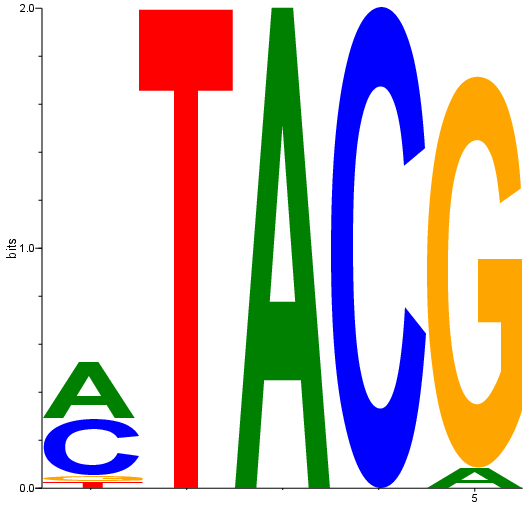

In [240]:
testpfm = GibbsMotifFinder(test_seqs, 5, 42)

sl.seqlogo(sl.CompletePm(pfm = testpfm.T))

In [365]:
subsample_pfm = GibbsMotifFinder(seqs=sequences_w_complement, k=38, seed=42)

max_iterations = 1000
50 iterations completed,
Frobenius diff: 0.03408291748207866
IC: 22.98102647463992
max_iterations = 1000
60 iterations completed,
Frobenius diff: 0.009764325593996238
IC: 22.993332865355185
max_iterations = 1000
70 iterations completed,
Frobenius diff: 0.009764806757590247
IC: 22.99435555306222
70 iterations completed,
Frobenius diff: 0.009764806757590247
IC: 22.99435555306222


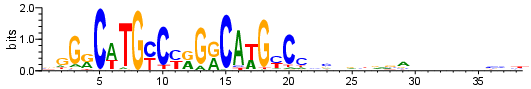

In [366]:
sl.seqlogo(sl.CompletePm(pfm = subsample_pfm.T))
#print(subsample_pfm)
#ic_scores = pfm_ic(subsample_pfm)
#print(ic_scores)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

In [ ]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_pfm.T))

In [ ]:
def get_consensus_sequence(pwm, threshold):
    pass
